# Constructing Brownian Motion

Construct Brownian motion from its defining properties and verify that the simulated paths exhibit the qualitative behavior predicted by theory.

## Questions

1. How does changing the timestep affect the appearance of the path?
2. How much variability is there between different realizations?
3. Do the paths visually appear nowhere differentiable?
4. Does Brownian motion exhibit self-similarity?

In [5]:
import importlib
import stochastic.brownian

importlib.reload(stochastic.brownian)

<module 'stochastic.brownian' from 'c:\\Users\\nanxi\\surim-brownian-exploration\\stochastic\\brownian.py'>

In [6]:
# Constructed Brownian motion!
import sys
from pathlib import Path

# Add the project root to Python's search path
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from stochastic.brownian import generate_brownian

import matplotlib.pyplot as plt

Text(0, 0.5, 'B(t)')

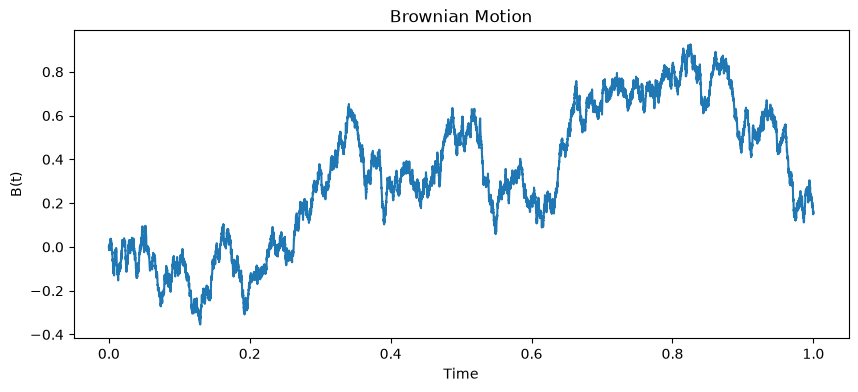

In [7]:
t, B = generate_brownian(n=10000)
plt.figure(figsize=(10,4))

plt.plot(t,B)

plt.title("Brownian Motion")

plt.xlabel("Time")

plt.ylabel("B(t)")

Text(0, 0.5, 'B(t)')

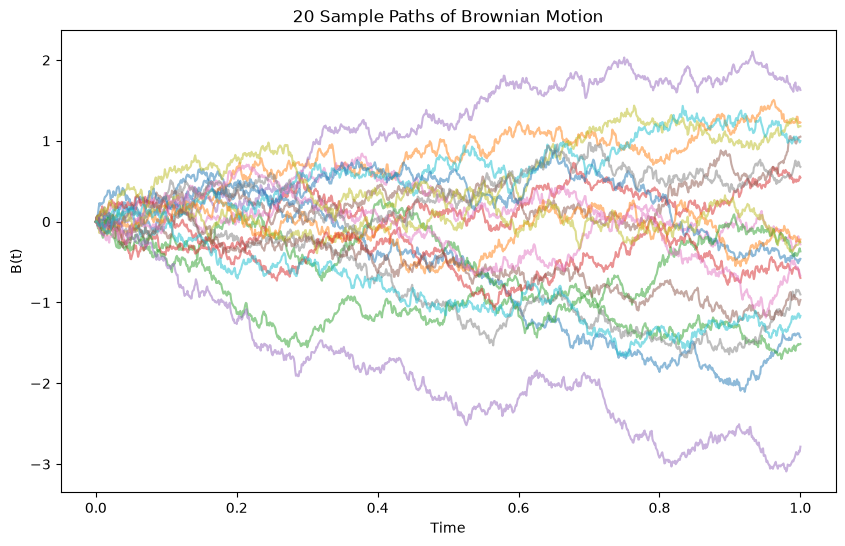

In [8]:
plt.figure(figsize=(10,6))

for i in range(20):
    t, B = generate_brownian(seed=i)
    plt.plot(t, B, alpha=0.5)

plt.title("20 Sample Paths of Brownian Motion")
plt.xlabel("Time")
plt.ylabel("B(t)")

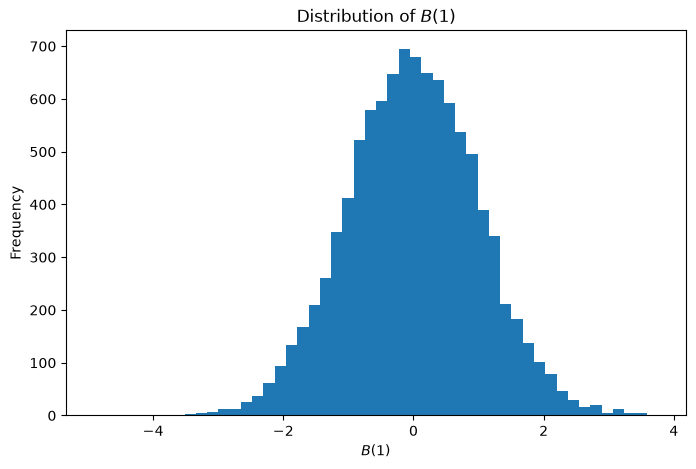

In [9]:
endpoints = []

for _ in range(10000):
    _, B = generate_brownian()
    endpoints.append(B[-1])
plt.figure(figsize=(8,5))

plt.hist(endpoints, bins=50)

plt.title(r"Distribution of $B(1)$")

plt.xlabel(r"$B(1)$")

plt.ylabel("Frequency")

plt.show()

# Quadratic Variation

## Questions
1. Does it actually converge to T
2. If we could in theory find another integrable stochastic process, it would have to satisfy some form of $$dB^2 = dt$$

In [10]:
from stochastic.brownian import generate_brownian
from analysis.variation import quadratic_variation
from analysis.variation import linear_variation


ns = [10, 20, 50, 100, 200, 500, 1000, 5000]

Q = []

for n in ns:
    _, B = generate_brownian(T=1, n=n)
    Q.append(quadratic_variation(B))

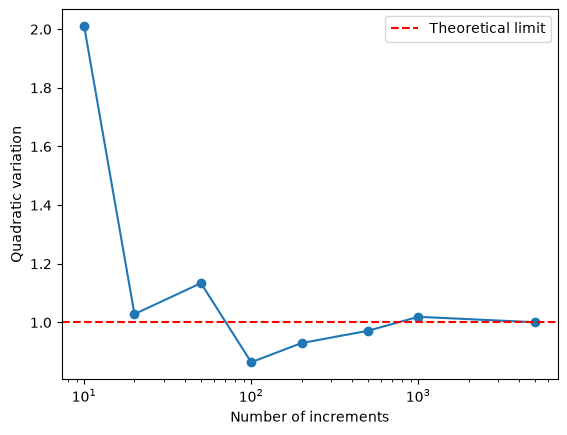

In [11]:
plt.plot(ns, Q, 'o-')
plt.axhline(1, color='red', linestyle='--', label='Theoretical limit')
plt.xscale('log')
plt.xlabel("Number of increments")
plt.ylabel("Quadratic variation")
plt.legend()
plt.show()

Note: for higher orders attempts, the integrals acrew different terms, making it less simple than brownian motion

# Fractional Brownian Motion (fBM)


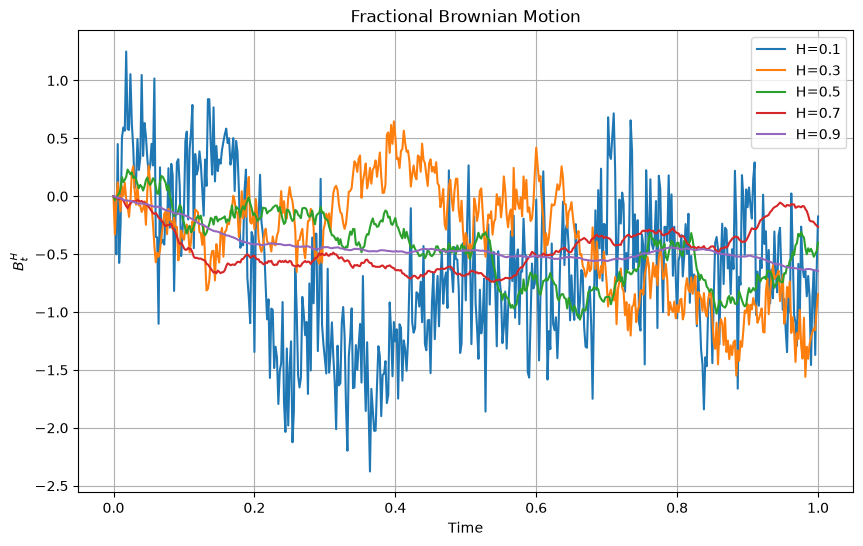

In [19]:
import matplotlib.pyplot as plt

from stochastic.fractional import generate_fractional

Hs = [0.1, 0.3, 0.5, 0.7, 0.9]

plt.figure(figsize=(10,6))

for H in Hs:
    t, B = generate_fractional(H=H, n=500)
    plt.plot(t, B, label=f"H={H}")

plt.legend()
plt.xlabel("Time")
plt.ylabel(r"$B_t^H$")
plt.title("Fractional Brownian Motion")
plt.grid(True)

plt.show()

In [ ]:
from stochastic.fractional import generate_fractional
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Hs = np.arange(0.05, 1.0, 0.05)
N = 100          # number of simulated paths
n = 100          # time discretization

records = []

for H in Hs:
    print(f"Simulating H = {H:.2f}")

    for i in range(N):
        _, B = generate_fractional(H=H, T=1, n=n)

        records.append({
            "H": f"{H:.2f}",
            "Maximum": np.max(B)
        })

df = pd.DataFrame(records)

Simulating H = 0.1
Simulating H = 0.1
Simulating H = 0.2
Simulating H = 0.2
Simulating H = 0.2
Simulating H = 0.3
Simulating H = 0.4
Simulating H = 0.4
Simulating H = 0.5
Simulating H = 0.5
Simulating H = 0.6
Simulating H = 0.6
Simulating H = 0.7
Simulating H = 0.7
Simulating H = 0.8
Simulating H = 0.8
Simulating H = 0.9
Simulating H = 0.9
Simulating H = 1.0


<Figure size 1000x600 with 0 Axes>

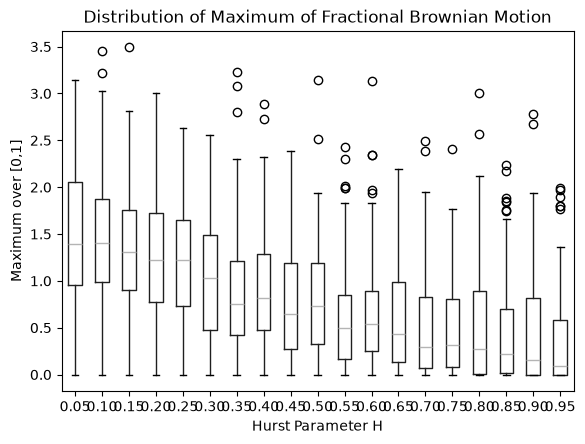

In [37]:
plt.figure(figsize=(10,6))

df.boxplot(
    column="Maximum",
    by="H",
    grid=False
)

plt.title("Distribution of Maximum of Fractional Brownian Motion")
plt.suptitle("")
plt.xlabel("Hurst Parameter H")
plt.ylabel("Maximum over [0,1]")

plt.show()

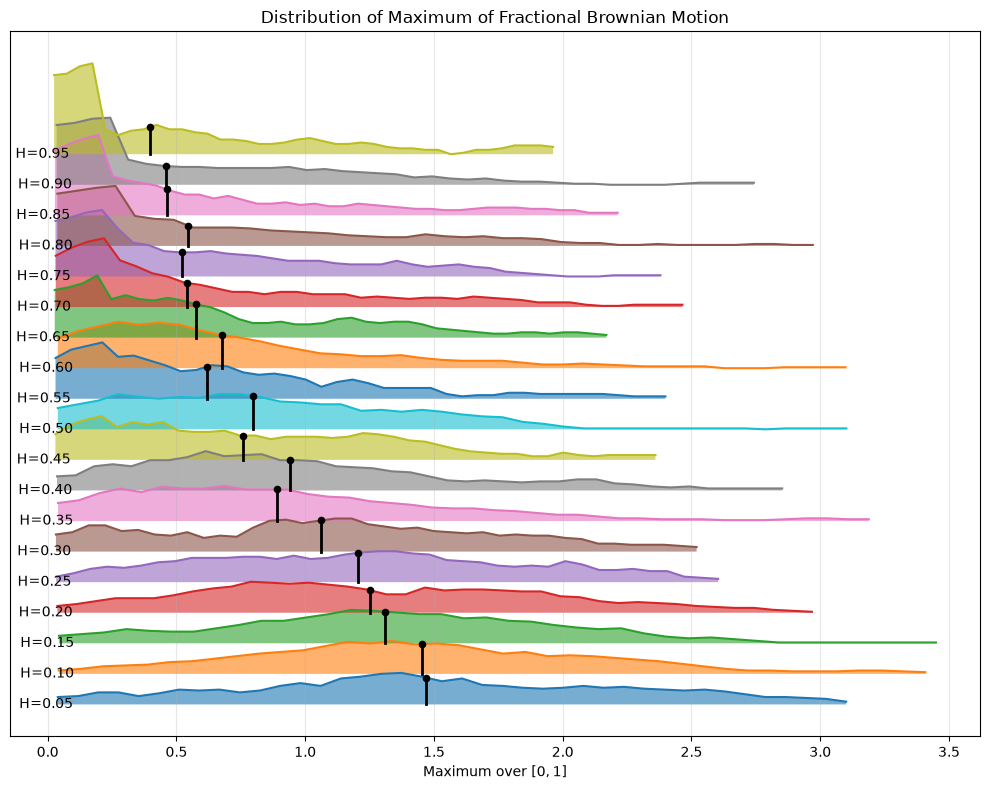

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------
# Assumes df has columns:
#   H        (strings like "0.1", "0.2", ...)
#   Maximum
# ----------------------------------------------------

def smooth(y, window=7):
    """Simple moving average smoother."""
    kernel = np.ones(window) / window
    return np.convolve(y, kernel, mode="same")


Hs = sorted(df["H"].unique(), key=float)

plt.figure(figsize=(10, 8))

offset = 0.6

for i, H in enumerate(Hs):

    data = df[df["H"] == H]["Maximum"].values

    # Histogram estimate
    density, bins = np.histogram(
        data,
        bins=40,
        density=True
    )

    x = 0.5 * (bins[:-1] + bins[1:])

    # Smooth density
    density = smooth(density, window=7)

    baseline = i * offset
    ridge = baseline + density

    # Filled ridge
    plt.fill_between(
        x,
        baseline,
        ridge,
        alpha=0.6
    )

    # Outline
    plt.plot(
        x,
        ridge,
        linewidth=1.5
    )

    # Mean of the distribution
    mean = np.mean(data)

    # Height of ridge at the mean (interpolate)
    mean_height = np.interp(mean, x, ridge)

    # Mean line
    plt.plot(
        [mean, mean],
        [baseline, mean_height],
        color="black",
        linewidth=2
    )

    # Mean dot
    plt.scatter(
        mean,
        mean_height,
        color="black",
        s=20,
        zorder=5
    )

    # H labels
    plt.text(
        x.min() - 0.15,
        baseline,
        f"H={H}",
        va="center",
        fontsize=10
    )

plt.xlabel("Maximum over $[0,1]$")
plt.yticks([])
plt.title("Distribution of Maximum of Fractional Brownian Motion")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()